# 07 — Entry-window decision

The baseline notebooks (00-05), the 06 post-IPO **calibration** review, and `PREDICTIONS.md` are **frozen** — written/scored under their own protocol, git history is the witness. This notebook is the *additive* entry-window layer: it overlays the realized price on the model's cone and records the first live trade decision, reading the immutable **`2026-07-06-entry-window`** checkpoint. Nothing here edits a prediction; it only measures the plan against reality.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

In [2]:
import json
CK = Path.cwd().parent / "checkpoints" / "2026-07-06-entry-window"
spcx = json.load(open(CK / "spcx_market.json"))
close = spcx.get("last_close") or spcx["ohlcv_tail"][-1]["Close"]
print(f"checkpoint 2026-07-06-entry-window | SPCX close {close:.2f} | identity_suspect={spcx['identity_suspect']}")

checkpoint 2026-07-06-entry-window | SPCX close 156.02 | identity_suspect=False


## 1. Identity resolution — the option chain is really SpaceX now

SpaceX IPO'd **2026-06-12** (Nasdaq: SPCX, priced \$135, day-1 close \$160.95, +19%). For the first days the free `SPCX` feed still resolved to the **defunct pre-2026 SPCX SPAC ETF** (strikes clustered ~\$25-32), so the Jun-13 checkpoint carried `identity_suspect: true`. On the entry-window checkpoint the strikes cluster around the real ~\$162 spot and the guard clears — the options are the correct instrument, not the ETF.

In [3]:
med = sorted(k for exp in spcx["option_chains"].values() for side in ("calls","puts") for k in [o["strike"] for o in exp[side]])
median_strike = med[len(med)//2] if med else float("nan")
print(f"median listed strike {median_strike:.1f} vs close {close:.1f} -> ratio {median_strike/close:.2f} (guard passes if 0.5-2.0)")
print(f"identity_suspect = {spcx['identity_suspect']}   quality_flags = {spcx['quality_flags']}")

median listed strike 172.5 vs close 156.0 -> ratio 1.11 (guard passes if 0.5-2.0)
identity_suspect = False   quality_flags = []


## 2. Frozen baseline vs realized parameters

`McConfig` stays the **frozen ex-ante model** (`spcx_s0=150`, `spcx_vol=0.70`, `debit=2.20`) — the same object notebook 06 scores its "assumed 70% vs realized IV" calibration against, so it is never mutated here. This notebook derives the **realized** inputs from archived checkpoint evidence and applies them explicitly: the last SPCX close (`spcx_ohlcv.parquet`), the **August (unlock-month) ATM implied vol** (`derived_atm_iv`, Black-Scholes-inverted from the option `lastPrice` because the free feed has no live bid/ask), and the 140/135 Sep put-spread debit BS-priced at that IV.

In [4]:
from src.risk.montecarlo import McConfig, SpreadPosition
from dataclasses import replace
from math import log, sqrt, erf, exp as _exp
import datetime as _dt

base_cfg, base_spread = McConfig(), SpreadPosition()               # frozen ex-ante model

real_close = float(pd.read_parquet(CK / "spcx_ohlcv.parquet")["Close"].iloc[-1])
aug = [v["avg_iv"] for e, v in spcx["derived_atm_iv"].items() if e.startswith("2026-08") and v["avg_iv"]]
real_vol = round(sum(aug)/len(aug), 3) if aug else base_cfg.spcx_vol   # Aug ATM IV, archived

def _bs_put(S, K, T, sig, r=0.036):
    if T <= 0 or sig <= 0: return max(0.0, K - S)
    nc = lambda x: 0.5 * (1 + erf(x / sqrt(2)))
    d1 = (log(S/K) + (r + 0.5*sig*sig)*T) / (sig*sqrt(T)); d2 = d1 - sig*sqrt(T)
    return K*_exp(-r*T)*nc(-d2) - S*nc(-d1)
asof = _dt.date.fromisoformat(str(spcx["ohlcv_tail"][-1]["Date"])[:10])
T_sep = (_dt.date(2026, 9, 18) - asof).days / 365
real_debit = round(_bs_put(real_close, 140, T_sep, real_vol) - _bs_put(real_close, 135, T_sep, real_vol), 2)

real_cfg = replace(base_cfg, spcx_s0=real_close, spcx_vol=real_vol)
real_spread = SpreadPosition(debit=real_debit)
pd.DataFrame({
    "baseline (ex-ante, frozen)": [base_cfg.spcx_s0, base_cfg.spcx_vol, base_spread.debit],
    "realized (entry window)": [round(real_cfg.spcx_s0, 2), real_cfg.spcx_vol, real_spread.debit],
}, index=["spcx_s0", "spcx_vol (Aug ATM IV)", "spread debit"])

,"baseline (ex-ante, frozen)",realized (entry window)
spcx_s0,150.0,156.020
spcx_vol (Aug ATM IV),0.7,0.877
spread debit,2.2,2.200


## 3. Monte Carlo re-run — hard cap must hold on every path

Same engine (GBM + Student-t fat tails + event-day jump), only the three parameters swapped. The structural claim to defend is that the debit spread's loss is **capped at the premium paid on every single path** — a design property, not a probabilistic one.

In [5]:
from src.risk.montecarlo import simulate, report
def run(cfg, spread):
    res = simulate(cfg, spread); rep = report(res)
    cap = spread.debit * 100 / cfg.fx_eurusd
    assert res["pnl_spread_eur"].min() >= -cap - 1e-6, "hard cap violated!"
    return res, rep, cap
base_res, base_rep, base_cap = run(base_cfg, base_spread)
real_res, real_rep, real_cap = run(real_cfg, real_spread)
print(f"hard cap holds on all {real_cfg.n_paths} paths | worst spread €{real_res['pnl_spread_eur'].min():.1f} vs cap -€{real_cap:.1f}")
pd.DataFrame({
    "baseline":  {k: round(base_rep[k],2) for k in ["p_loss","VaR95","ES95","mean","worst_path"]},
    "realized":  {k: round(real_rep[k],2) for k in ["p_loss","VaR95","ES95","mean","worst_path"]},
})

hard cap holds on all 10000 paths | worst spread €-189.7 vs cap -€189.7


,baseline,realized
p_loss,0.38,0.39
VaR95,306.41,310.56
ES95,378.18,380.12
mean,69.22,63.51
worst_path,-619.63,-619.63


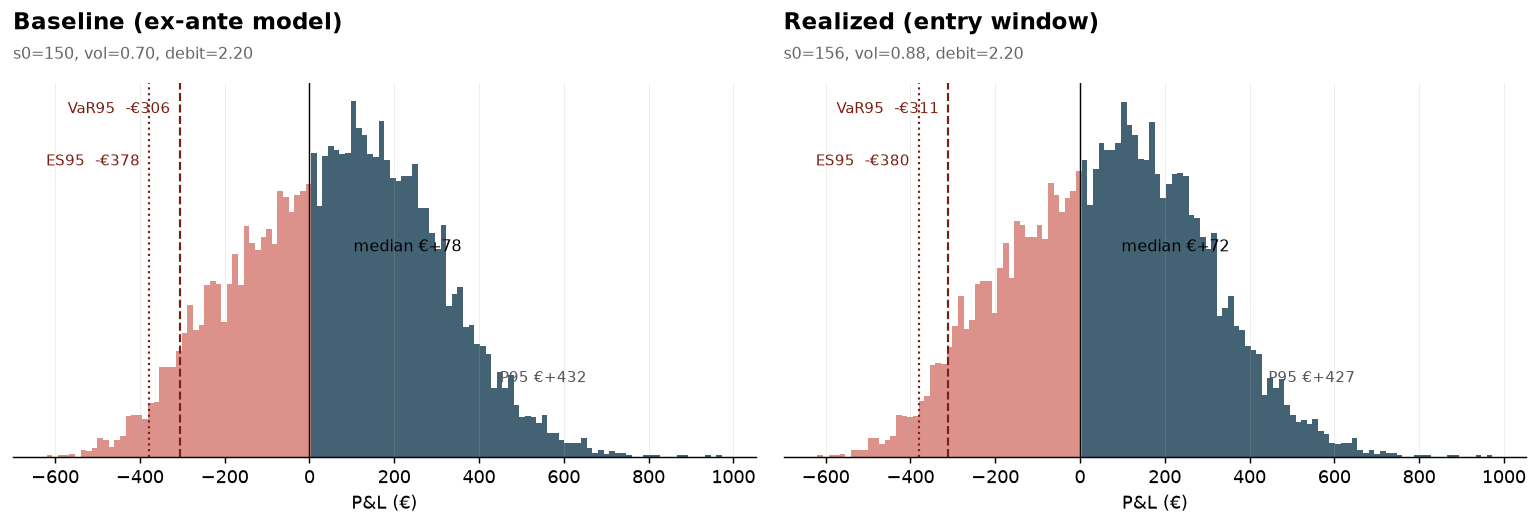

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
pnl_distribution(axes[0], base_res["pnl_total_eur"], base_rep["VaR95"], base_rep["ES95"],
                 "Baseline (ex-ante model)", f"s0={base_cfg.spcx_s0:.0f}, vol={base_cfg.spcx_vol:.2f}, debit={base_spread.debit:.2f}")
pnl_distribution(axes[1], real_res["pnl_total_eur"], real_rep["VaR95"], real_rep["ES95"],
                 "Realized (entry window)", f"s0={real_cfg.spcx_s0:.0f}, vol={real_cfg.spcx_vol:.2f}, debit={real_spread.debit:.2f}")
plt.tight_layout(); plt.savefig("../assets/chart_pnl_baseline_vs_real.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Monte Carlo cone vs the price that actually materialized

The core AI-in-finance question: did reality land inside the model's forecast cone? The fan below is 4,000 Student-t Monte Carlo paths anchored at the **Jun 12 IPO close**, propagated with the realized IV. The realized SPCX closes (Jun 12 → last checkpoint) are overlaid — this is the model meeting the market.

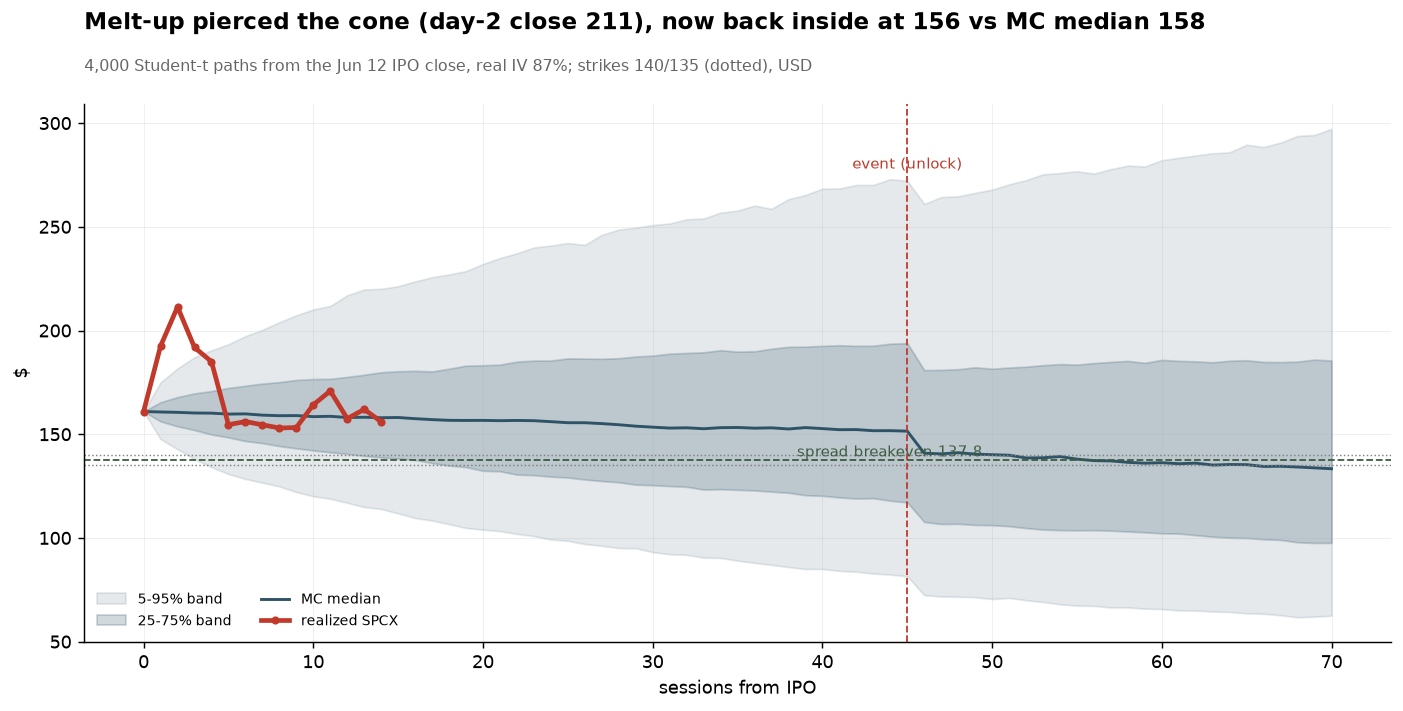

In [7]:
from src.risk.montecarlo import TRADING_DAYS
spx = pd.read_parquet(CK / "spcx_ohlcv.parquet")["Close"]  # committed evidence, reproducible for third parties
realized = spx.values; ipo_anchor = float(realized[0])
rng = np.random.default_rng(real_cfg.seed); H = real_cfg.horizon_days; dt = 1/TRADING_DAYS
scale = np.sqrt(real_cfg.t_dof/(real_cfg.t_dof-2))
z = rng.standard_t(real_cfg.t_dof, (4000, H))/scale
paths = np.empty((4000, H+1)); paths[:, 0] = ipo_anchor
for d in range(H):
    paths[:, d+1] = paths[:, d]*np.exp((real_cfg.spcx_drift - 0.5*real_cfg.spcx_vol**2)*dt + real_cfg.spcx_vol*np.sqrt(dt)*z[:, d])
    if d == real_cfg.event_day:
        paths[:, d+1] *= np.exp(rng.normal(real_cfg.jump_mean, real_cfg.jump_std, 4000))
days = np.arange(H+1); q = {p: np.percentile(paths, p, axis=0) for p in (5, 25, 50, 75, 95)}
be = real_spread.long_strike - real_spread.debit
fig, ax = plt.subplots(figsize=(11, 5.6))
ax.fill_between(days, q[5], q[95], color=PALETTE[0], alpha=0.12, label="5-95% band")
ax.fill_between(days, q[25], q[75], color=PALETTE[0], alpha=0.22, label="25-75% band")
ax.plot(days, q[50], color=PALETTE[0], lw=1.6, label="MC median")
ax.plot(np.arange(len(realized)), realized, color=BAD, lw=2.6, marker="o", ms=3.5, label="realized SPCX")
for k in (real_spread.long_strike, real_spread.short_strike):
    ax.axhline(k, ls=":", color="gray", lw=0.8)
ax.axhline(be, ls="--", color="#3d5c40", lw=1); ax.annotate(f"spread breakeven {be:.1f}", (H*0.55, be+1.5), color="#3d5c40", fontsize=8.5)
ax.axvline(real_cfg.event_day, ls="--", color=PALETTE[1], lw=1); ax.annotate("event (unlock)", (real_cfg.event_day, ax.get_ylim()[1]*0.9), color=PALETTE[1], fontsize=8.5, ha="center")
headline(ax, f"Melt-up pierced the cone (day-2 close {realized[:5].max():.0f}), now back inside at {realized[-1]:.0f} vs MC median {q[50][len(realized)-1]:.0f}",
         "4,000 Student-t paths from the Jun 12 IPO close, real IV 87%; strikes 140/135 (dotted), USD")
ax.set_xlabel("sessions from IPO"); ax.set_ylabel("$"); ax.legend(loc="lower left", fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig("../assets/chart_mc_vs_realized.png", dpi=130, bbox_inches="tight"); plt.show()

## 5. The entry decision — IV gate not met, stand-down

Strategy B enters only when **all three** Phase-2 conditions hold at once. On 2026-07-06 the IV crush the plan waited for has not arrived: SPCX still trades at post-IPO frenzy vol (~83-87%) against a ≤55% gate. Per **Phase 2 Fallback 1**, buying options here is a gift to the market maker — no order is placed; retry Jul 24 at the relaxed 60% threshold (which ~83% still fails), else cancel Strategy B. This is a *valid* outcome: the plan's discipline held. See `docs/06-trade-journal.md` §2 #001.

In [8]:
gate = pd.DataFrame([
    ["ATM IV (Aug unlock)", "< 55%", f"~{real_vol:.0%}", real_vol < 0.55],
    ["SPCX spot", "> $140", f"${real_close:.2f}", real_close > 140],
    ["140/135 Sep debit", "<= $2.30", f"~${real_spread.debit:.2f}", real_spread.debit <= 2.30],
], columns=["condition", "threshold", "realized", "met"])
print("ENTRY DECISION:", "ENTER" if gate["met"].all() else "STAND-DOWN (no order)")
gate

ENTRY DECISION: STAND-DOWN (no order)


,condition,threshold,realized,met
0,ATM IV (Aug unlock),< 55%,~88%,False
1,SPCX spot,> $140,$156.02,True
2,140/135 Sep debit,<= $2.30,~$2.20,True
